In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from keras import datasets, layers, models, optimizers

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, multilabel_confusion_matrix

In [2]:
iris_dataset = datasets.load_iris()

data = pd.DataFrame({
    'sepal_length': iris_dataset.data[:, 0],
    'sepal_width': iris_dataset.data[:, 1],
    'petal_length': iris_dataset.data[:, 2],
    'petal_width': iris_dataset.data[:, 3],
    'species': iris_dataset.target
})

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X = data.drop(columns=['species'])
y = data['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [4]:
sc = StandardScaler()

scaler = sc.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dense(12, activation='relu'),
    layers.Dense(3, activation='softmax')
])

optimizer = optimizers.Adam(learning_rate=0.001)

model.compile(
    loss='sparse_categorical_crossentropy',
	optimizer=optimizer,
	metrics=['accuracy']
)

model.summary()

2026-02-07 13:24:43.230418: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-02-07 13:24:43.230461: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-07 13:24:43.230471: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-02-07 13:24:43.230710: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-07 13:24:43.231063: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                80        
                                                                 
 dense_1 (Dense)             (None, 12)                204       
                                                                 
 dense_2 (Dense)             (None, 3)                 39        
                                                                 
Total params: 323 (1.26 KB)
Trainable params: 323 (1.26 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
history = model.fit(X_train, y_train, epochs=500, batch_size=64)

Epoch 1/500


2026-02-07 13:24:43.810985: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-02-07 13:24:43.839431: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


2/2 [==============================] - 1s 102ms/step - loss: 0.7059 - accuracy: 0.6667
Epoch 2/500
2/2 [==============================] - 0s 10ms/step - loss: 0.6804 - accuracy: 0.6762
Epoch 3/500
2/2 [==============================] - 0s 7ms/step - loss: 0.6558 - accuracy: 0.6762
Epoch 4/500
2/2 [==============================] - 0s 8ms/step - loss: 0.6362 - accuracy: 0.6762
Epoch 5/500
2/2 [==============================] - 0s 9ms/step - loss: 0.6166 - accuracy: 0.6952
Epoch 6/500
2/2 [==============================] - 0s 9ms/step - loss: 0.5982 - accuracy: 0.6857
Epoch 7/500
2/2 [==============================] - 0s 8ms/step - loss: 0.5799 - accuracy: 0.6952
Epoch 8/500
2/2 [==============================] - 0s 9ms/step - loss: 0.5657 - accuracy: 0.7143
Epoch 9/500
2/2 [==============================] - 0s 11ms/step - loss: 0.5503 - accuracy: 0.7333
Epoch 10/500
2/2 [==============================] - 0s 7ms/step - loss: 0.5366 - accuracy: 0.7524
Epoch 11/500
2/2 [===================

In [7]:
class_names = ['Setosa', 'Versicolor', 'Virginica']
pred_df = pd.DataFrame(X_test, columns=['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth'])

pred_probs = model.predict(X_test)
predicted_class_index = np.argmax(pred_probs, axis=1)

pred_df['prediction'] = [class_names[idx] for idx in predicted_class_index]
pred_df['max_probability'] = np.max(pred_probs, axis=1)

pred_df

2/2 [==============================] - 0s 13ms/step


,SepalLength,SepalWidth,PetalLength,PetalWidth,prediction,max_probability
0,0.288093,-0.116671,0.488473,0.272865,Versicolor,0.984547
1,-0.805271,-0.772944,0.085071,0.272865,Versicolor,0.990247
2,-0.197847,-0.116671,0.257958,0.006346,Versicolor,0.978399
3,-1.534180,0.320844,-1.355650,-1.326253,Setosa,0.999723
4,0.774032,0.320844,0.776617,1.072425,Virginica,0.964166
5,0.409577,-0.335428,0.315587,0.139606,Versicolor,0.996627
6,1.259971,0.320844,1.122390,1.472205,Virginica,0.999836
7,0.166608,-1.866731,0.142700,-0.260174,Versicolor,0.999873
8,1.017002,0.102087,0.546102,0.406125,Versicolor,0.985474
9,0.288093,-0.991701,1.064761,0.272865,Virginica,0.854466


Accuracy : 0.9777777777777777


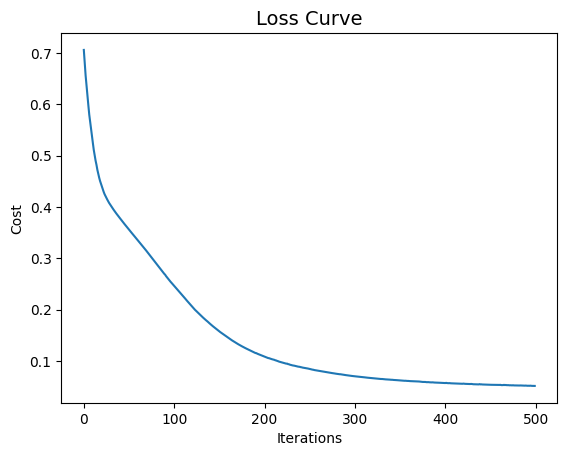

In [9]:
acc_model_tf = accuracy_score(y_test, predicted_class_index)
print("Accuracy :", acc_model_tf)

plt.plot(history.history['loss'])
plt.title("Loss Curve", fontsize=14)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

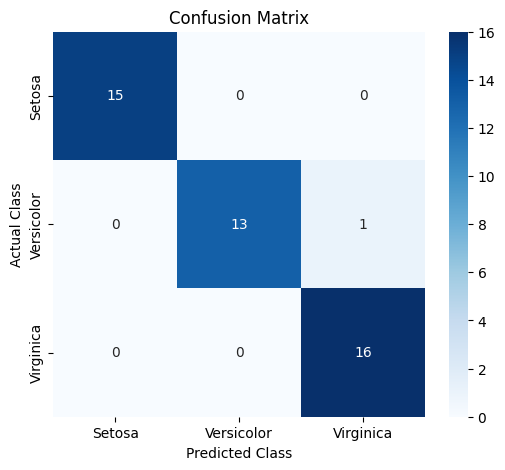

In [14]:
cm = confusion_matrix(y_test, predicted_class_index)

plt.figure(figsize=(6, 5))
class_names = ['Setosa', 'Versicolor', 'Virginica']

sns.heatmap(
    cm, 
	annot=True,
	fmt='d',
	cmap='Blues',
	xticklabels=class_names, 
	yticklabels=class_names
)

plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix')
plt.show()

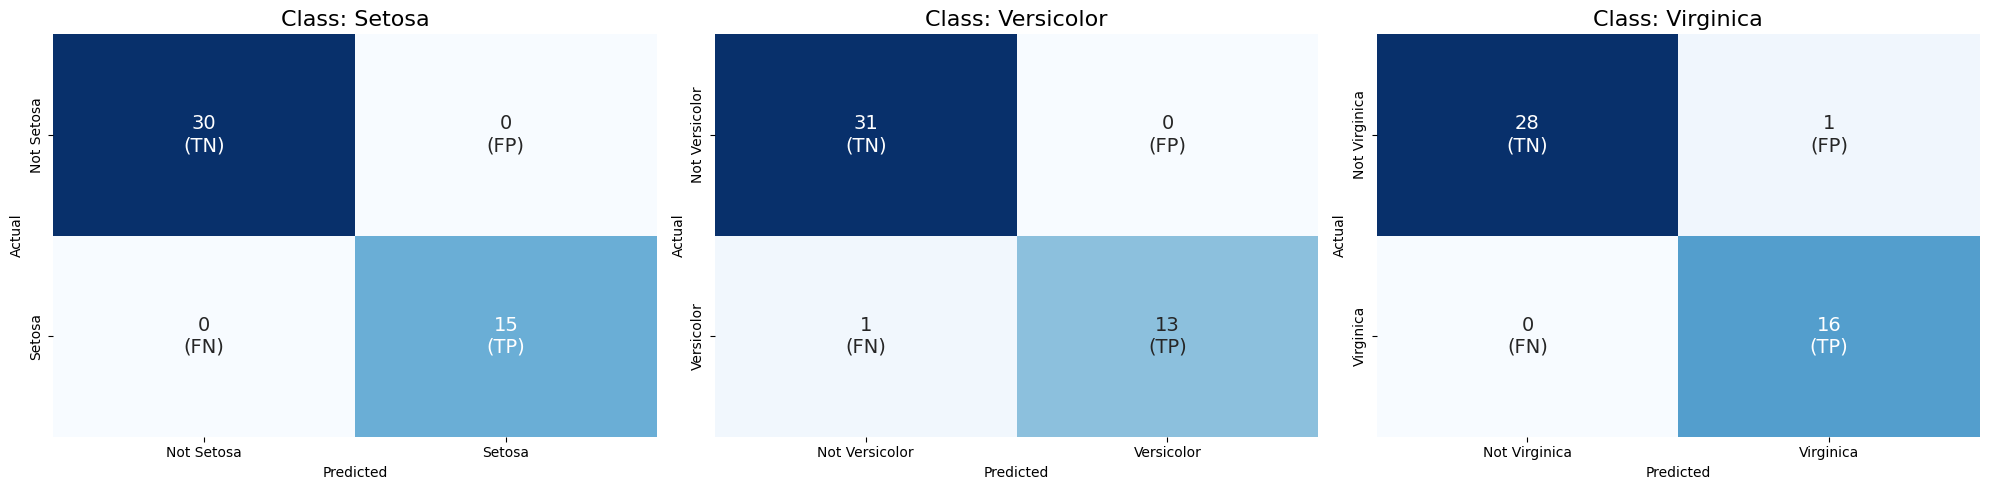

In [17]:
mcm = multilabel_confusion_matrix(y_test, predicted_class_index)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
class_names = ['Setosa', 'Versicolor', 'Virginica']

for i, (matrix, name) in enumerate(zip(mcm, class_names)):

    labels = [f"{matrix[0,0]}\n(TN)", f"{matrix[0,1]}\n(FP)",
              f"{matrix[1,0]}\n(FN)", f"{matrix[1,1]}\n(TP)"]
    
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(matrix, annot=labels, fmt='', cmap='Blues', 
                cbar=False, ax=axes[i], annot_kws={"size": 14})
    
    axes[i].set_title(f"Class: {name}", fontsize=16)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
    
    axes[i].set_xticklabels([f'Not {name}', name])
    axes[i].set_yticklabels([f'Not {name}', name])

plt.tight_layout()
plt.show()